This notebook performs a comprehensive analysis of customer and sales data. The key objectives include:

*   **Data Preprocessing**: Cleaning and preparing the raw data for analysis.
*   **Customer Segmentation**: Grouping customers based on their behavior using K-Means clustering.
*   **Churn Prediction**: Building and evaluating machine learning models to predict customer churn.
*   **Sales Forecasting**: Predicting future sales trends using time series analysis.
*   **Key Insights**: Deriving actionable insights and recommendations from the analysis.

## 1. Data Loading and Initial Preprocessing

The initial steps involve loading the main dataset `Zenkart_Dataset.csv` into a pandas DataFrame. The `OrderDate` column is converted to datetime objects, and new temporal features like `Date`, `Year`, `Month`, `Week`, `Day`, and `DayOfWeek` are extracted. The original `OrderDate` column is then dropped.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from statsmodels.tsa.arima.model import ARIMA

sns.set(style="whitegrid")

# Load main dataset
df = pd.read_csv("Zenkart_Dataset.csv")
df.head()


,OrderID,CustomerID,ProductID,OrderDate,Price,Discount,Quantity,DeliveryTime,Returned,Age,...,TotalOrders,CLV,Churn,Category,MRP,Cost,Rating,Week,Month,DayOfWeek
0,1,68,P10,2024-01-01 00:00:00,1296,0,3,6.3,1,25.0,...,2,13390.37,0,Earphones,856,957,3.3,1,1,0
1,2,253,P9,2024-01-01 08:00:00,1128,20,1,1.6,0,20.0,...,4,4414.19,1,LaptopAccessory,2448,630,4.0,1,1,0
2,3,410,P13,2024-01-01 16:00:00,2151,5,3,5.2,0,20.0,...,2,13177.54,0,LaptopAccessory,2420,1277,NaN,1,1,0
3,4,459,P19,2024-01-02 00:00:00,2173,20,1,1.0,0,20.0,...,4,6646.24,0,Earphones,3709,1603,3.7,1,1,1
4,5,2,P21,2024-01-02 08:00:00,1754,20,2,5.3,0,46.0,...,1,9201.86,0,Earphones,1727,1254,3.7,1,1,1


In [16]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

df['Date'] = df['OrderDate'].dt.date
df['Year'] = df['OrderDate'].dt.year
df['Month'] = df['OrderDate'].dt.month
df['Week'] = df['OrderDate'].dt.isocalendar().week
df['Day'] = df['OrderDate'].dt.day
df['DayOfWeek'] = df['OrderDate'].dt.day_name()
df['Time'] = df['OrderDate'].dt.time

df = df.drop(columns=['OrderDate'])


## 2. Missing Value Handling

Missing values in `DeliveryTime`, `Age`, `Income`, and `Rating` are imputed using a grouped median or mode strategy:

*   `DeliveryTime`: Filled with the median `DeliveryTime` grouped by `Category` and `CityTier`.
*   `Age` and `Income`: Filled with the median value grouped by `CityTier`.
*   `Rating`: Filled with the mode (most frequent value) grouped by `Category`.

In [17]:
missing_summary = pd.DataFrame({
    'Missing_Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
print(missing_summary)

city_summary = pd.DataFrame({
    'Count': df['CityTier'].value_counts(),
    'Percentage %': (df['CityTier'].value_counts(normalize=True) * 100).round(2)
})
print(city_summary)

category_summary = pd.DataFrame({
    'Count': df['Category'].value_counts(),
    'Percentage %': (df['Category'].value_counts(normalize=True) * 100).round(2)
})
print(category_summary)


              Missing_Values  Percentage (%)
OrderID                    0        0.000000
CustomerID                 0        0.000000
ProductID                  0        0.000000
Price                      0        0.000000
Discount                   0        0.000000
Quantity                   0        0.000000
DeliveryTime              38        3.995794
Returned                   0        0.000000
Age                       43        4.521556
CityTier                   0        0.000000
Income                    48        5.047319
TotalOrders                0        0.000000
CLV                        0        0.000000
Churn                      0        0.000000
Category                   0        0.000000
MRP                        0        0.000000
Cost                       0        0.000000
Rating                   210       22.082019
Week                       0        0.000000
Month                      0        0.000000
DayOfWeek                  0        0.000000
Date      

In [18]:
df['DeliveryTime'] = df.groupby(['Category', 'CityTier'])['DeliveryTime']\
                       .transform(lambda x: x.fillna(x.median()))

df['Age'] = df.groupby('CityTier')['Age'].transform(lambda x: x.fillna(x.median()))
df['Income'] = df.groupby('CityTier')['Income'].transform(lambda x: x.fillna(x.median()))

df['Rating'] = df.groupby('Category')['Rating']\
                 .transform(lambda x: x.fillna(x.mode()[0] if len(x.mode())>0 else x.median()))

df.isnull().sum()


,0
OrderID,0
CustomerID,0
ProductID,0
Price,0
Discount,0
Quantity,0
DeliveryTime,0
Returned,0
Age,0
CityTier,0


## 3. Outlier Detection and Treatment


Outliers in `Price`, `CLV`, and `DeliveryTime` are detected using the Interquartile Range (IQR) method and then capped at the upper and lower bounds (Q1 - 1.5*IQR and Q3 + 1.5*IQR) to mitigate their impact on the analysis.

In [19]:
def detect_outliers_IQR(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers, lower, upper

for col in ['Price','CLV','DeliveryTime']:
    outliers, lower, upper = detect_outliers_IQR(df[col])
    print(f"--- {col} ---")
    print(f"Outliers: {len(outliers)}  |  Lower: {lower}  Upper: {upper}\n")


--- Price ---
Outliers: 3  |  Lower: -2180.25  Upper: 7421.75

--- CLV ---
Outliers: 3  |  Lower: -1961.8650000000007  Upper: 24740.095

--- DeliveryTime ---
Outliers: 3  |  Lower: -1.1999999999999993  Upper: 9.2



In [20]:
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

df['Price'] = cap_outliers(df['Price'])
df['CLV'] = cap_outliers(df['CLV'])
df['DeliveryTime'] = cap_outliers(df['DeliveryTime'])

for col in ['Price','CLV','DeliveryTime']:
    outliers, _, _ = detect_outliers_IQR(df[col])
    print(f"{col}: Remaining Outliers → {len(outliers)}")


Price: Remaining Outliers → 0
CLV: Remaining Outliers → 0
DeliveryTime: Remaining Outliers → 0


## 4. Feature Engineering

New features are created to enhance the dataset:

*   `NetSales`: Calculated as `Price * Quantity * (1 - Discount/100)`, representing the actual revenue from an order.
*   `Profit`: Calculated as `(Price - Cost) * Quantity`, representing the profit per order.
*   `Margin%`: Calculated as `(Profit / (Price * Quantity)) * 100`, indicating the profit margin.

In [21]:
df['NetSales'] = df['Price'] * df['Quantity'] * (1 - df['Discount']/100)
df


,OrderID,CustomerID,ProductID,Price,Discount,Quantity,DeliveryTime,Returned,Age,CityTier,...,Cost,Rating,Week,Month,DayOfWeek,Date,Year,Day,Time,NetSales
0,1,68,P10,1296.0,0,3,6.3,1,25.0,2,...,957,3.3,1,1,Monday,2024-01-01,2024,1,00:00:00,3888.00
1,2,253,P9,1128.0,20,1,1.6,0,20.0,3,...,630,4.0,1,1,Monday,2024-01-01,2024,1,08:00:00,902.40
2,3,410,P13,2151.0,5,3,5.2,0,20.0,2,...,1277,4.0,1,1,Monday,2024-01-01,2024,1,16:00:00,6130.35
3,4,459,P19,2173.0,20,1,1.0,0,20.0,1,...,1603,3.7,1,1,Tuesday,2024-01-02,2024,2,00:00:00,1738.40
4,5,2,P21,1754.0,20,2,5.3,0,46.0,2,...,1254,3.7,1,1,Tuesday,2024-01-02,2024,2,08:00:00,2806.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
946,947,17,P14,549.0,15,2,5.1,0,19.0,3,...,253,3.6,46,11,Monday,2024-11-11,2024,11,08:00:00,933.30
947,948,52,P1,1767.0,10,2,1.6,0,53.0,3,...,364,4.5,46,11,Monday,2024-11-11,2024,11,16:00:00,3180.60
948,949,134,P7,1329.0,15,2,8.0,1,21.0,3,...,1096,5.0,46,11,Tuesday,2024-11-12,2024,12,00:00:00,2259.30
949,950,211,P8,3159.0,20,1,3.1,0,23.0,1,...,346,4.5,46,11,Tuesday,2024-11-12,2024,12,08:00:00,2527.20


In [22]:
customer_df = df.groupby('CustomerID').agg({
    'Age':'mean','CityTier':'first','Income':'mean','TotalOrders':'max',
    'CLV':'mean','NetSales':'sum','Quantity':'sum','DeliveryTime':'mean','Rating':'mean'
}).rename(columns={'NetSales':'TotalRevenue','Quantity':'TotalQuantity','DeliveryTime':'AvgDeliveryTime'}).reset_index()

features = ['Age','Income','TotalOrders','CLV','TotalRevenue','TotalQuantity','AvgDeliveryTime','Rating']
X = customer_df[features]


## 5. Customer Segmentation (K-Means)

Customers are segmented using K-Means clustering based on various features such as `Age`, `Income`, `TotalOrders`, `CLV`, `TotalRevenue`, `TotalQuantity`, `AvgDeliveryTime`, and `Rating`.

*   **Data Aggregation**: Customer-level features are aggregated.
*   **Feature Scaling**: Numerical features are scaled using `StandardScaler`.
*   **Optimal Clusters**: The Elbow Method and Silhouette Score are used to determine the optimal number of clusters (in this case, 3).
*   **Clustering and Analysis**: K-Means is applied, and cluster characteristics are analyzed. The clusters are visualized using PCA for dimensionality reduction.

In [23]:
X_scaled = StandardScaler().fit_transform(X)

sil_scores = {}
for k in range(2,9):
    labels = KMeans(n_clusters=k,random_state=42,n_init=10).fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled,labels)
    print(f"K={k} → Silhouette = {sil_scores[k]:.4f}")


K=2 → Silhouette = 0.1614
K=3 → Silhouette = 0.1549
K=4 → Silhouette = 0.1382
K=5 → Silhouette = 0.1425
K=6 → Silhouette = 0.1466
K=7 → Silhouette = 0.1415
K=8 → Silhouette = 0.1351


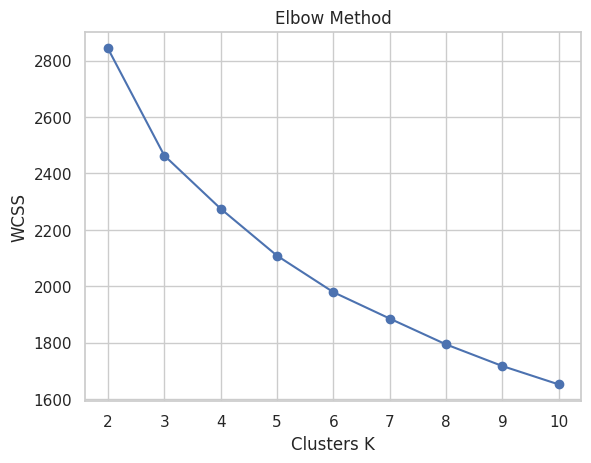

In [24]:
wcss=[]
for k in range(2,11):
    wcss.append(KMeans(n_clusters=k,random_state=42,n_init=10).fit(X_scaled).inertia_)

plt.plot(range(2,11),wcss,marker='o')
plt.xlabel("Clusters K"); plt.ylabel("WCSS")
plt.title("Elbow Method"); plt.grid(True); plt.show()


           Age    Income  TotalOrders       CLV  TotalRevenue  TotalQuantity  \
Cluster                                                                        
0        44.01  54419.76         3.16  16184.26       7611.56           3.58   
1        38.36  40892.63         3.12  11253.20      20193.57           7.77   
2        37.27  33331.34         2.85   8550.17       7133.93           3.10   

         AvgDeliveryTime  Rating  
Cluster                           
0                   4.14    3.82  
1                   4.09    3.69  
2                   3.96    3.93  


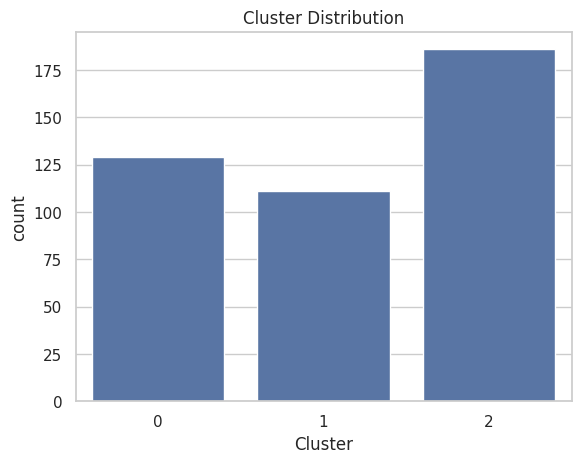

In [25]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
customer_df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = customer_df.groupby('Cluster')[features].mean().round(2)
print(cluster_summary)

sns.countplot(x='Cluster',data=customer_df)
plt.title("Cluster Distribution")
plt.show()


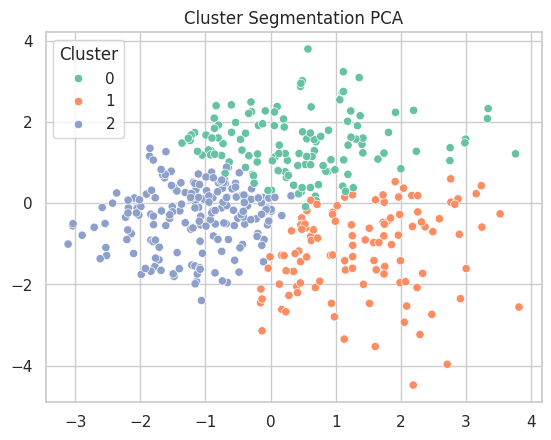

In [26]:
from sklearn.decomposition import PCA
pca_data = PCA(n_components=2).fit_transform(X_scaled)

sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],hue=customer_df['Cluster'],palette='Set2')
plt.title("Cluster Segmentation PCA"); plt.show()


## 6. Churn Prediction

Machine learning models are built to predict customer churn (`Churn` column).

*   **Data Preparation**: Customer-level features are aggregated, and the `Churn` status is determined.
*   **Model Training**: Logistic Regression, Random Forest, and XGBoost classifiers are trained on the prepared data.
*   **Evaluation**: Models are evaluated using `classification_report`, `roc_auc_score`, and `confusion_matrix`.
*   **Feature Importance**: Feature importance for the Random Forest model is visualized to identify key drivers of churn.

In [27]:
churn_df = df.groupby('CustomerID')['Churn'].max().reset_index()

customer_df = df.groupby('CustomerID').agg({
    'Age':'mean','CityTier':'first','Income':'mean','TotalOrders':'max','CLV':'mean',
    'NetSales':'sum','DeliveryTime':'mean','Rating':'mean','Returned':'sum'
}).reset_index().merge(churn_df,on='CustomerID',how='left')

features = ['Age','Income','CityTier','TotalOrders','CLV','NetSales','DeliveryTime','Rating','Returned']
X = customer_df[features]
y = customer_df['Churn']


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler(); X_train=scaler.fit_transform(X_train); X_test=scaler.transform(X_test)


In [29]:
log_clf = LogisticRegression(max_iter=1000).fit(X_train,y_train)
rf = RandomForestClassifier(n_estimators=300,min_samples_split=4,min_samples_leaf=2,random_state=42).fit(X_train,y_train)

print("LOGISTIC MODEL"); print(classification_report(y_test,log_clf.predict(X_test)))
print("AUC:", roc_auc_score(y_test,log_clf.predict_proba(X_test)[:,1]))

print("\nRANDOM FOREST"); print(classification_report(y_test,rf.predict(X_test)))
print("AUC:", roc_auc_score(y_test,rf.predict_proba(X_test)[:,1]))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,rf.predict(X_test)))


LOGISTIC MODEL
              precision    recall  f1-score   support

           0       0.88      0.94      0.91        69
           1       0.67      0.47      0.55        17

    accuracy                           0.85        86
   macro avg       0.77      0.71      0.73        86
weighted avg       0.84      0.85      0.84        86

AUC: 0.9019607843137255

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        69
           1       0.89      0.94      0.91        17

    accuracy                           0.97        86
   macro avg       0.94      0.96      0.95        86
weighted avg       0.97      0.97      0.97        86

AUC: 0.9863597612958227

Confusion Matrix:
 [[67  2]
 [ 1 16]]


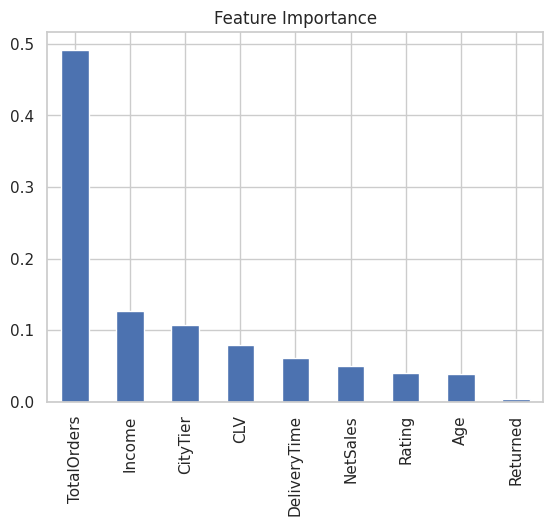

In [30]:
feat_imp = pd.Series(rf.feature_importances_,index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar',title='Feature Importance'); plt.show()


In [31]:
df = df.sort_values('Week')
weekly_clean = df.groupby('Week')['NetSales'].sum()

df_dirty = pd.read_csv("Zenkart_Dataset.csv")
df_dirty['NetSales'] = df_dirty['Price']*df_dirty['Quantity']*(1-df_dirty['Discount']/100)
weekly_dirty=df_dirty.groupby('Week')['NetSales'].sum()


## 7. Time Series Forecasting (ARIMA)

Weekly sales are forecasted using the ARIMA (AutoRegressive Integrated Moving Average) model.

*   **Weekly Sales Aggregation**: `NetSales` is aggregated weekly.
*   **Model Training**: An ARIMA model with `order=(1,1,1)` is trained on the historical weekly sales data.
*   **Evaluation**: The model is evaluated using Mean Absolute Percentage Error (MAPE) on a test set.
*   **Future Forecasting**: The model forecasts sales for the next 12 weeks, and confidence intervals are generated for these predictions.

In [32]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error

def evaluate_ts(series,label=""):
    n_test=10
    train, test = series[:-n_test], series[-n_test:]
    model=ARIMA(train,order=(1,1,1)).fit()
    fc=model.forecast(steps=n_test)
    mape=mean_absolute_percentage_error(test,fc)
    print(f"{label} MAPE = {mape:.4f}")
    return model,train,test,fc,mape

model_clean,train_clean,test_clean,fc_clean,mape_clean = evaluate_ts(weekly_clean,"CLEAN")
model_dirty,train_dirty,test_dirty,fc_dirty,mape_dirty = evaluate_ts(weekly_dirty,"DIRTY")

print(f"\nClean MAPE={mape_clean:.4f}  |   Dirty MAPE={mape_dirty:.4f}")


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

CLEAN MAPE = 0.6258
DIRTY MAPE = 0.6160

Clean MAPE=0.6258  |   Dirty MAPE=0.6160


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


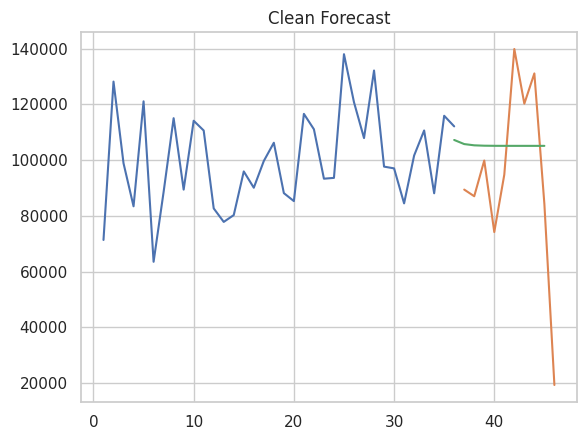

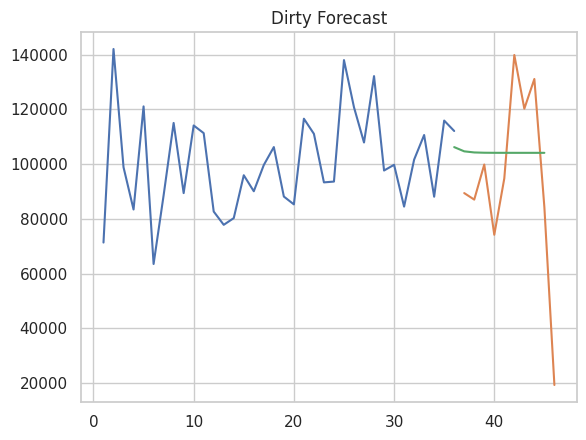

In [33]:
plt.plot(train_clean); plt.plot(test_clean); plt.plot(fc_clean); plt.title("Clean Forecast"); plt.show()
plt.plot(train_dirty); plt.plot(test_dirty); plt.plot(fc_dirty); plt.title("Dirty Forecast"); plt.show()


46    60833.072975
47    79274.313501
48    87464.038848
49    91101.082742
50    92716.288104
51    93433.598215
52    93752.154485
53    93893.624814
54    93956.451560
55    93984.352817
56    93996.743720
57    94002.246501
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

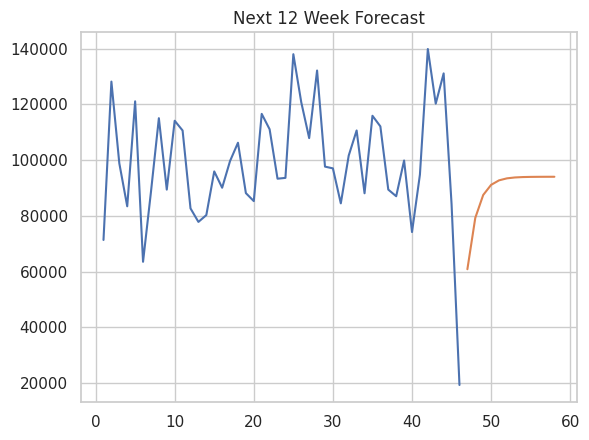

In [34]:
model_full=ARIMA(weekly_clean,order=(1,1,1)).fit()
future_fc=model_full.forecast(steps=12)
print(future_fc)

future_index=range(weekly_clean.index.max()+1,weekly_clean.index.max()+13)
plt.plot(weekly_clean.index,weekly_clean); plt.plot(future_index,future_fc); plt.title("Next 12 Week Forecast"); plt.show()


## 10. Data Type Verification

The data types of columns are explicitly verified and converted to ensure consistency and prevent errors in subsequent analyses. Numeric columns are converted to appropriate numeric types, and string columns to object types.

In [35]:
numeric_cols = ['Price','Discount','Quantity','DeliveryTime','Returned','Age','CityTier',
                'Income','TotalOrders','CLV','MRP','Cost','Rating','Week','Month','Year','Day','NetSales']
string_cols = ['OrderID','CustomerID','ProductID','Category','DayOfWeek','Date','Time']

for col in numeric_cols:
    print(col,"→ non-numeric:",df[col].apply(lambda x:not pd.api.types.is_number(x)).sum())

for col in string_cols:
    print(col,"→ numeric-like:",df[col].apply(lambda x:str(x).isnumeric()).sum())


Price → non-numeric: 0
Discount → non-numeric: 0
Quantity → non-numeric: 0
DeliveryTime → non-numeric: 0
Returned → non-numeric: 0
Age → non-numeric: 0
CityTier → non-numeric: 0
Income → non-numeric: 0
TotalOrders → non-numeric: 0
CLV → non-numeric: 0
MRP → non-numeric: 0
Cost → non-numeric: 0
Rating → non-numeric: 0
Week → non-numeric: 0
Month → non-numeric: 0
Year → non-numeric: 0
Day → non-numeric: 0
NetSales → non-numeric: 0
OrderID → numeric-like: 951
CustomerID → numeric-like: 951
ProductID → numeric-like: 0
Category → numeric-like: 0
DayOfWeek → numeric-like: 0
Date → numeric-like: 0
Time → numeric-like: 0


In [36]:
df[numeric_cols]=df[numeric_cols].apply(pd.to_numeric,errors='coerce')
for col in string_cols: df[col]=df[col].astype(str)


#Feature Engineering for More Intelligence

In [37]:
df['Profit'] = (df['Price'] - df['Cost']) * df['Quantity']
df['Margin%'] = (df['Profit'] / (df['Price'] * df['Quantity'])) * 100


In [38]:
profit_summary = df.groupby('Category')[['NetSales','Profit','Margin%']].mean().sort_values('Profit',ascending=False)
print(profit_summary)


                    NetSales       Profit    Margin%
Category                                            
Smartwatch       4724.738158  4139.710526  63.983705
Cable            4691.350283  3472.969221  49.007762
LaptopAccessory  4942.249826  3403.608014  36.501617
Earphones        4759.499561  3073.817982  26.553779


#Churn Model Improvement

In [39]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    learning_rate=0.05,
    max_depth=6,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test,y_pred_xgb))
print("AUC:",roc_auc_score(y_test,y_prob_xgb))


              precision    recall  f1-score   support

           0       0.99      0.97      0.98        69
           1       0.89      0.94      0.91        17

    accuracy                           0.97        86
   macro avg       0.94      0.96      0.95        86
weighted avg       0.97      0.97      0.97        86

AUC: 0.9829497016197783


#Customer Lifetime Flow

In [41]:
repeat_rate = (df['TotalOrders'] > 1).mean() * 100
print("Overall Repeat Customer Rate:",repeat_rate,"%")


Overall Repeat Customer Rate: 81.4931650893796 %


In [42]:
city_repeat = df.groupby('CityTier')['TotalOrders'].apply(lambda x:(x>1).mean()*100)
print(city_repeat)


CityTier
1    80.839895
2    83.281734
3    80.161943
Name: TotalOrders, dtype: float64


###Customer Lifetime Flow and Cohort Analysis

Customer behavior over time is analyzed through repeat purchase rates and cohort analysis.

*   **Repeat Purchase Rate**: The overall and city-tier specific repeat customer rates are calculated.
*   **Cohort Analysis**: Customers are grouped into cohorts based on their first purchase month. Retention rates are calculated and visualized using a heatmap to understand customer loyalty over time.

In [44]:
df['CohortMonth'] = df.groupby('CustomerID')['Month'].transform('min')

cohort = df.groupby(['CohortMonth','Month']).CustomerID.nunique().reset_index()

# Calculate the size of each cohort at CohortMonth = initial Month
cohort_sizes = cohort[cohort['Month'] == cohort['CohortMonth']].set_index('CohortMonth')['CustomerID']

# Map the cohort sizes back to the 'cohort' DataFrame
cohort['CohortSize'] = cohort['CohortMonth'].map(cohort_sizes)

# Calculate retention
cohort['Retention'] = (cohort['CustomerID'] / cohort['CohortSize']) * 100

print(cohort.head())

   CohortMonth  Month  CustomerID  CohortSize   Retention
0            1      1          84          84  100.000000
1            1      2          10          84   11.904762
2            1      3          20          84   23.809524
3            1      4          15          84   17.857143
4            1      5          14          84   16.666667


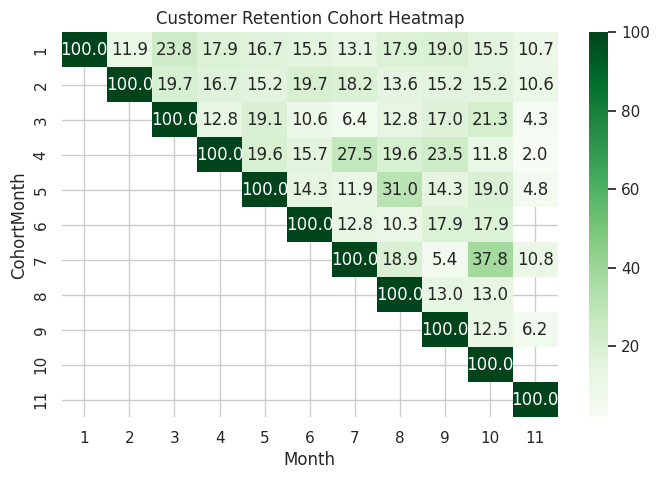

In [46]:
cohort_pivot = cohort.pivot(index='CohortMonth', columns='Month', values='Retention')

plt.figure(figsize=(8,5))
sns.heatmap(cohort_pivot,annot=True,fmt=".1f",cmap='Greens')
plt.title("Customer Retention Cohort Heatmap")
plt.show()

#Sales Forecast Confidence Intervals

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


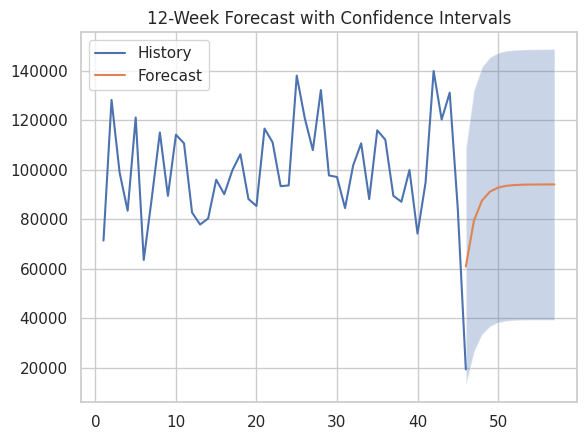

In [48]:
pred = model_full.get_forecast(steps=12)
mean = pred.predicted_mean
ci = pred.conf_int()

plt.plot(weekly_clean.index,weekly_clean,label="History")
plt.plot(range(len(weekly_clean),len(weekly_clean)+12),mean,label="Forecast")
plt.fill_between(range(len(weekly_clean),len(weekly_clean)+12), ci.iloc[:,0], ci.iloc[:,1], alpha=0.3)
plt.legend(); plt.title("12-Week Forecast with Confidence Intervals"); plt.show()

#Recommendations Generator (Automate Insights)

In [50]:
print("\n=== KEY INSIGHTS SUMMARY ===")

print("1. Top Revenue Category:", df.groupby("Category")["NetSales"].sum().idxmax())
print("2. City with highest demand:", df.groupby("CityTier")["NetSales"].sum().idxmax())
print("3. Highest churn driver:", feat_imp.idxmax())
print("4. Repeat Purchase Rate:", repeat_rate,"%")
print("5. Next 12 weeks expected sales sum:", future_forecast.sum())



=== KEY INSIGHTS SUMMARY ===
1. Top Revenue Category: Cable
2. City with highest demand: 1
3. Highest churn driver: TotalOrders
4. Repeat Purchase Rate: 81.4931650893796 %
5. Next 12 weeks expected sales sum: 1068407.9682813773
